In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.3f}'.format)

# Set plot style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


In [2]:
# Load the dataset
DATA_PATH = '../dataset_with_all_targets_present.csv'

print("Loading AquaSat dataset...")
df = pd.read_csv(DATA_PATH)

print(f"✅ Dataset loaded: {len(df):,} records")

Loading AquaSat dataset...
✅ Dataset loaded: 57,268 records


## 1. Understanding Water Quality Parameters

### 1.1 Parameter Definitions

| Parameter | Name | Unit | Significance | Good Water = |
|-----------|------|------|--------------|-------------|
| **chl_a** | Chlorophyll-a | μg/L | Indicator of algal biomass | LOW values |
| **tss** | Total Suspended Solids | mg/L | Measure of turbidity/sediment | LOW values |
| **secchi** | Secchi Disk Depth | meters | Water transparency measure | HIGH values |

### 1.2 Key Insight for Classification

**Good quality water** is characterized by:
- ⬇️ LOW chlorophyll-a (minimal algae)
- ⬇️ LOW suspended solids (clear water)
- ⬆️ HIGH Secchi depth (high transparency)

**Poor quality water** is characterized by:
- ⬆️ HIGH chlorophyll-a (algal blooms)
- ⬆️ HIGH suspended solids (turbid water)
- ⬇️ LOW Secchi depth (low transparency)

In [3]:
# Examine current distributions of target parameters
TARGET_PARAMS = ['chl_a', 'tss', 'secchi']

print(f"{'='*60}")
print(f"WATER QUALITY PARAMETER DISTRIBUTIONS")
print(f"{'='*60}")

for param in TARGET_PARAMS:
    data = df[param]
    print(f"\n📊 {param.upper()}:")
    print(f"   Min: {data.min():.3f}")
    print(f"   25th percentile: {data.quantile(0.25):.3f}")
    print(f"   Median (50th): {data.quantile(0.50):.3f}")
    print(f"   75th percentile: {data.quantile(0.75):.3f}")
    print(f"   90th percentile: {data.quantile(0.90):.3f}")
    print(f"   Max: {data.max():.3f}")

WATER QUALITY PARAMETER DISTRIBUTIONS

📊 CHL_A:
   Min: 0.017
   25th percentile: 4.071
   Median (50th): 8.850
   75th percentile: 19.440
   90th percentile: 41.066
   Max: 907.000

📊 TSS:
   Min: 0.100
   25th percentile: 5.200
   Median (50th): 10.000
   75th percentile: 19.376
   90th percentile: 35.000
   Max: 3420.000

📊 SECCHI:
   Min: 0.000
   25th percentile: 0.508
   Median (50th): 0.900
   75th percentile: 1.400
   90th percentile: 2.100
   Max: 49.000


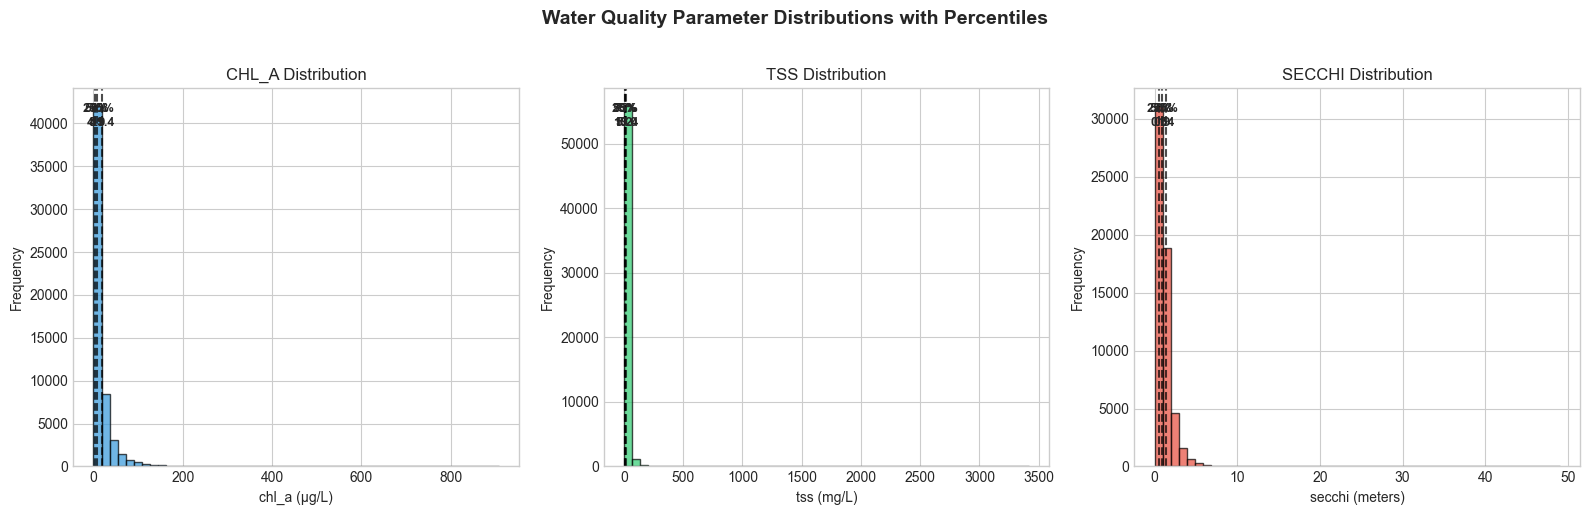

In [4]:
# Visualize distributions with percentile markers
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

colors = ['#3498db', '#2ecc71', '#e74c3c']
units = ['μg/L', 'mg/L', 'meters']

for i, (param, color, unit) in enumerate(zip(TARGET_PARAMS, colors, units)):
    ax = axes[i]
    data = df[param]
    
    # Histogram
    ax.hist(data, bins=50, color=color, alpha=0.7, edgecolor='black')
    
    # Add percentile lines
    percentiles = [25, 50, 75]
    for p in percentiles:
        val = data.quantile(p/100)
        ax.axvline(val, color='black', linestyle='--', linewidth=1.5, alpha=0.7)
        ax.text(val, ax.get_ylim()[1]*0.9, f'{p}%\n{val:.1f}', 
                ha='center', fontsize=9, fontweight='bold')
    
    ax.set_xlabel(f'{param} ({unit})')
    ax.set_ylabel('Frequency')
    ax.set_title(f'{param.upper()} Distribution')

plt.suptitle('Water Quality Parameter Distributions with Percentiles', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 2. Threshold Definition Strategy

### 2.1 Scientific Guidelines Reference

We base our thresholds on multiple sources:

**EPA Guidelines (US):**
- Chlorophyll-a: <10 μg/L (oligotrophic) → Good; 10-25 μg/L (mesotrophic) → Moderate; >25 μg/L (eutrophic) → Poor
- Secchi depth: >3m → Good; 1.5-3m → Moderate; <1.5m → Poor

**EU Water Framework Directive:**
- Uses similar trophic state classifications

**Literature Review:**
- Carlson Trophic State Index (TSI)
- OECD eutrophication criteria

### 2.2 Our Approach: Combined Score

Rather than using a single parameter, we'll create a **composite water quality score** based on all three parameters, then classify into three categories.

**Strategy:**
1. Normalize each parameter to 0-1 scale
2. For chl_a and tss: higher = worse (inverted)
3. For secchi: higher = better (direct)
4. Compute average normalized score
5. Classify based on score ranges

In [5]:
# Define thresholds based on data percentiles and scientific guidelines
print(f"{'='*60}")
print(f"THRESHOLD DEFINITION ANALYSIS")
print(f"{'='*60}")

# Calculate percentile-based thresholds
thresholds = {
    'chl_a': {
        'good_upper': df['chl_a'].quantile(0.33),  # Lower 33%  → Good
        'poor_lower': df['chl_a'].quantile(0.67)   # Upper 33% → Poor
    },
    'tss': {
        'good_upper': df['tss'].quantile(0.33),
        'poor_lower': df['tss'].quantile(0.67)
    },
    'secchi': {
        'poor_upper': df['secchi'].quantile(0.33),  # Lower 33% → Poor (inverted)
        'good_lower': df['secchi'].quantile(0.67)   # Upper 33% → Good
    }
}

print("\n📏 Data-Driven Percentile Thresholds (33rd/67th):")
print("\n  Chlorophyll-a (lower is better):")
print(f"    • Good: chl_a < {thresholds['chl_a']['good_upper']:.2f} μg/L")
print(f"    • Moderate: {thresholds['chl_a']['good_upper']:.2f} - {thresholds['chl_a']['poor_lower']:.2f} μg/L")
print(f"    • Poor: chl_a > {thresholds['chl_a']['poor_lower']:.2f} μg/L")

print("\n  Total Suspended Solids (lower is better):")
print(f"    • Good: tss < {thresholds['tss']['good_upper']:.2f} mg/L")
print(f"    • Moderate: {thresholds['tss']['good_upper']:.2f} - {thresholds['tss']['poor_lower']:.2f} mg/L")
print(f"    • Poor: tss > {thresholds['tss']['poor_lower']:.2f} mg/L")

print("\n  Secchi Depth (higher is better):")
print(f"    • Good: secchi > {thresholds['secchi']['good_lower']:.2f} m")
print(f"    • Moderate: {thresholds['secchi']['poor_upper']:.2f} - {thresholds['secchi']['good_lower']:.2f} m")
print(f"    • Poor: secchi < {thresholds['secchi']['poor_upper']:.2f} m")

THRESHOLD DEFINITION ANALYSIS

📏 Data-Driven Percentile Thresholds (33rd/67th):

  Chlorophyll-a (lower is better):
    • Good: chl_a < 5.30 μg/L
    • Moderate: 5.30 - 14.70 μg/L
    • Poor: chl_a > 14.70 μg/L

  Total Suspended Solids (lower is better):
    • Good: tss < 6.80 mg/L
    • Moderate: 6.80 - 15.70 mg/L
    • Poor: tss > 15.70 mg/L

  Secchi Depth (higher is better):
    • Good: secchi > 1.20 m
    • Moderate: 0.60 - 1.20 m
    • Poor: secchi < 0.60 m


## 3. Creating the Water Quality Score

### 3.1 Normalization Approach

We'll use **percentile-based normalization** to create a composite score:

1. For each parameter, calculate its percentile rank (0-100)
2. For chl_a and tss: invert (100 - percentile) so higher = better
3. For secchi: use directly (higher = better)
4. Average the three normalized scores
5. Classify based on the composite score

In [6]:
# Create normalized scores for each parameter
print(f"{'='*60}")
print(f"CREATING NORMALIZED WATER QUALITY SCORES")
print(f"{'='*60}")

# Calculate percentile ranks (0-100)
# For chl_a: lower is better, so invert
df['chl_a_score'] = 100 - df['chl_a'].rank(pct=True) * 100

# For tss: lower is better, so invert
df['tss_score'] = 100 - df['tss'].rank(pct=True) * 100

# For secchi: higher is better, use directly
df['secchi_score'] = df['secchi'].rank(pct=True) * 100

# Calculate composite water quality score (average of three scores)
df['wq_score'] = (df['chl_a_score'] + df['tss_score'] + df['secchi_score']) / 3

print("\n✅ Normalized scores created:")
print("   • chl_a_score (higher = better water quality)")
print("   • tss_score (higher = better water quality)")
print("   • secchi_score (higher = better water quality)")
print("   • wq_score (composite, higher = better)")

print(f"\n📊 Composite Water Quality Score Distribution:")
print(f"   Min: {df['wq_score'].min():.2f}")
print(f"   25th percentile: {df['wq_score'].quantile(0.25):.2f}")
print(f"   Median: {df['wq_score'].median():.2f}")
print(f"   75th percentile: {df['wq_score'].quantile(0.75):.2f}")
print(f"   Max: {df['wq_score'].max():.2f}")

CREATING NORMALIZED WATER QUALITY SCORES

✅ Normalized scores created:
   • chl_a_score (higher = better water quality)
   • tss_score (higher = better water quality)
   • secchi_score (higher = better water quality)
   • wq_score (composite, higher = better)

📊 Composite Water Quality Score Distribution:
   Min: 0.18
   25th percentile: 32.46
   Median: 50.37
   75th percentile: 67.36
   Max: 99.50


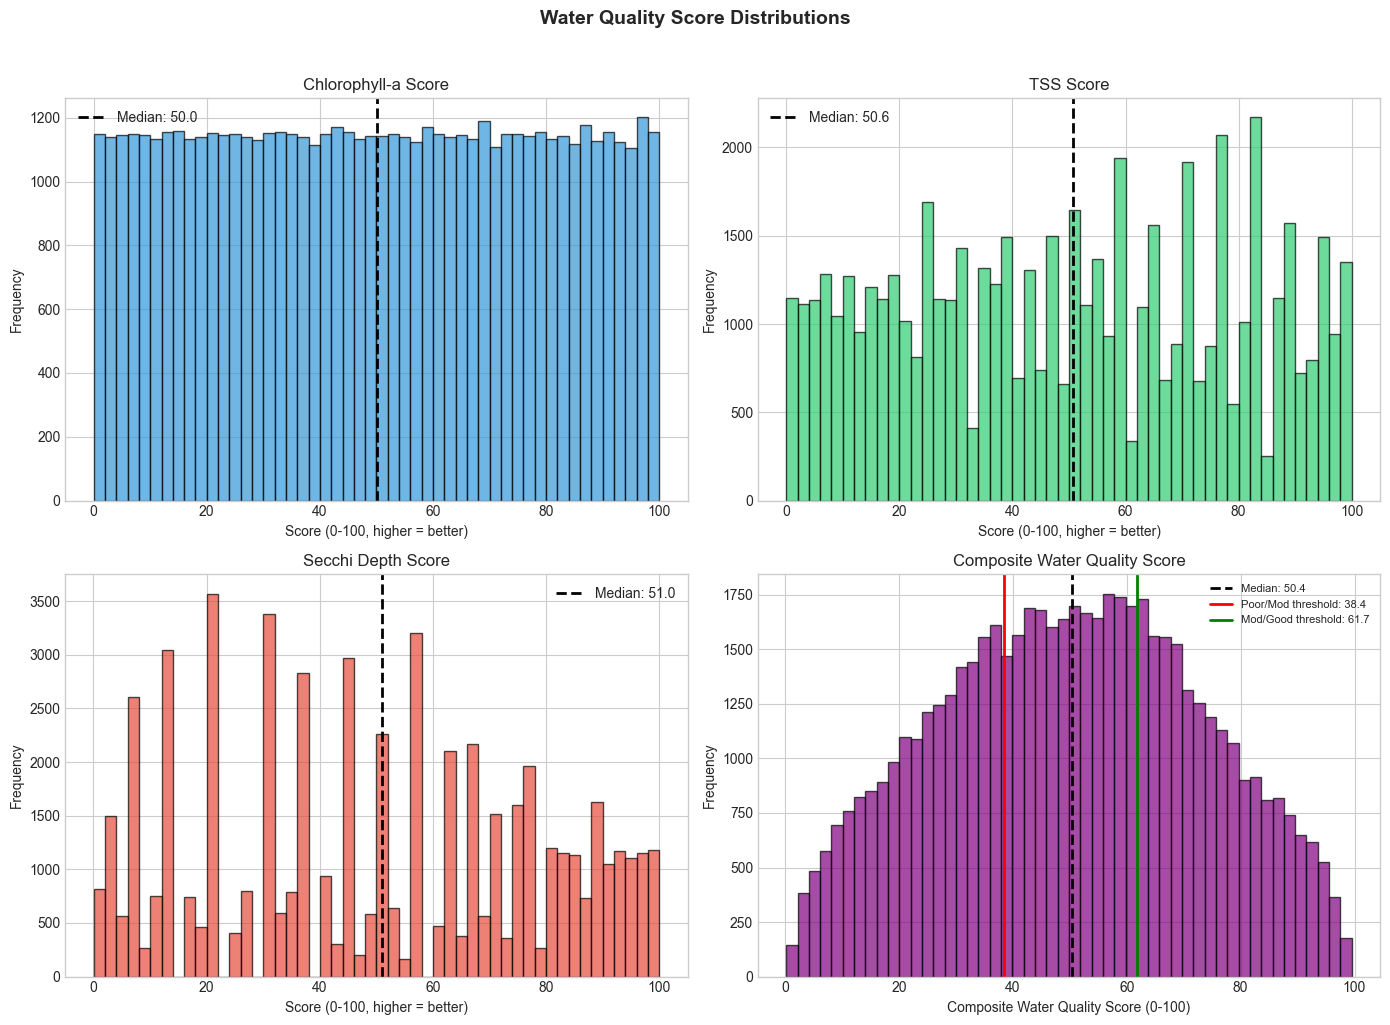

In [7]:
# Visualize the composite score distribution
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Individual parameter scores
score_cols = ['chl_a_score', 'tss_score', 'secchi_score']
colors = ['#3498db', '#2ecc71', '#e74c3c']
titles = ['Chlorophyll-a Score', 'TSS Score', 'Secchi Depth Score']

for i, (col, color, title) in enumerate(zip(score_cols, colors, titles)):
    row = i // 2
    col_idx = i % 2
    ax = axes[row, col_idx]
    
    ax.hist(df[col], bins=50, color=color, alpha=0.7, edgecolor='black')
    ax.axvline(df[col].median(), color='black', linestyle='--', linewidth=2, label=f'Median: {df[col].median():.1f}')
    ax.set_xlabel('Score (0-100, higher = better)')
    ax.set_ylabel('Frequency')
    ax.set_title(title)
    ax.legend()

# Composite score
ax = axes[1, 1]
ax.hist(df['wq_score'], bins=50, color='purple', alpha=0.7, edgecolor='black')
ax.axvline(df['wq_score'].median(), color='black', linestyle='--', linewidth=2, label=f'Median: {df["wq_score"].median():.1f}')

# Add threshold lines for Good/Moderate/Poor
threshold_33 = df['wq_score'].quantile(0.33)
threshold_67 = df['wq_score'].quantile(0.67)

ax.axvline(threshold_33, color='red', linestyle='-', linewidth=2, label=f'Poor/Mod threshold: {threshold_33:.1f}')
ax.axvline(threshold_67, color='green', linestyle='-', linewidth=2, label=f'Mod/Good threshold: {threshold_67:.1f}')

ax.set_xlabel('Composite Water Quality Score (0-100)')
ax.set_ylabel('Frequency')
ax.set_title('Composite Water Quality Score')
ax.legend(fontsize=8)

plt.suptitle('Water Quality Score Distributions', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 4. Creating Water Quality Classes

### 4.1 Classification Strategy

We'll use the composite water quality score to create three balanced classes:

| Class | Condition | Description |
|-------|-----------|-------------|
| **Good** | wq_score ≥ 67th percentile | Clear water, low algae, high transparency |
| **Moderate** | 33rd percentile ≤ wq_score < 67th percentile | Some degradation |
| **Poor** | wq_score < 33rd percentile | High algae/turbidity, low transparency |

This approach ensures roughly balanced classes (~33% each).

In [8]:
# Define class thresholds based on percentiles
print(f"{'='*60}")
print(f"CREATING WATER QUALITY CLASSES")
print(f"{'='*60}")

# Calculate thresholds
threshold_poor_moderate = df['wq_score'].quantile(0.33)
threshold_moderate_good = df['wq_score'].quantile(0.67)

print(f"\n📏 Class Thresholds (based on composite score):")
print(f"   • Poor: wq_score < {threshold_poor_moderate:.2f}")
print(f"   • Moderate: {threshold_poor_moderate:.2f} ≤ wq_score < {threshold_moderate_good:.2f}")
print(f"   • Good: wq_score ≥ {threshold_moderate_good:.2f}")

# Create the target variable
def assign_water_quality_class(score):
    if score < threshold_poor_moderate:
        return 'Poor'
    elif score < threshold_moderate_good:
        return 'Moderate'
    else:
        return 'Good'

df['water_quality_class'] = df['wq_score'].apply(assign_water_quality_class)

print(f"\n✅ Target variable 'water_quality_class' created!")

CREATING WATER QUALITY CLASSES

📏 Class Thresholds (based on composite score):
   • Poor: wq_score < 38.40
   • Moderate: 38.40 ≤ wq_score < 61.71
   • Good: wq_score ≥ 61.71

✅ Target variable 'water_quality_class' created!


In [9]:
# Verify class distribution
print(f"\n{'='*60}")
print(f"CLASS DISTRIBUTION ANALYSIS")
print(f"{'='*60}")

class_counts = df['water_quality_class'].value_counts()
class_percentages = df['water_quality_class'].value_counts(normalize=True) * 100

print("\n📊 Class Distribution:")
for class_name in ['Good', 'Moderate', 'Poor']:
    count = class_counts.get(class_name, 0)
    pct = class_percentages.get(class_name, 0)
    print(f"   • {class_name}: {count:,} samples ({pct:.1f}%)")

# Check for imbalance
imbalance_ratio = class_counts.max() / class_counts.min()
print(f"\n📐 Class Imbalance Ratio: {imbalance_ratio:.2f}")

if imbalance_ratio < 1.5:
    print("   ✅ Classes are well-balanced!")
elif imbalance_ratio < 3:
    print("   ⚠️ Mild imbalance detected - may need stratification")
else:
    print("   ❌ Significant imbalance - will need resampling strategies")


CLASS DISTRIBUTION ANALYSIS

📊 Class Distribution:
   • Good: 18,899 samples (33.0%)
   • Moderate: 19,470 samples (34.0%)
   • Poor: 18,899 samples (33.0%)

📐 Class Imbalance Ratio: 1.03
   ✅ Classes are well-balanced!


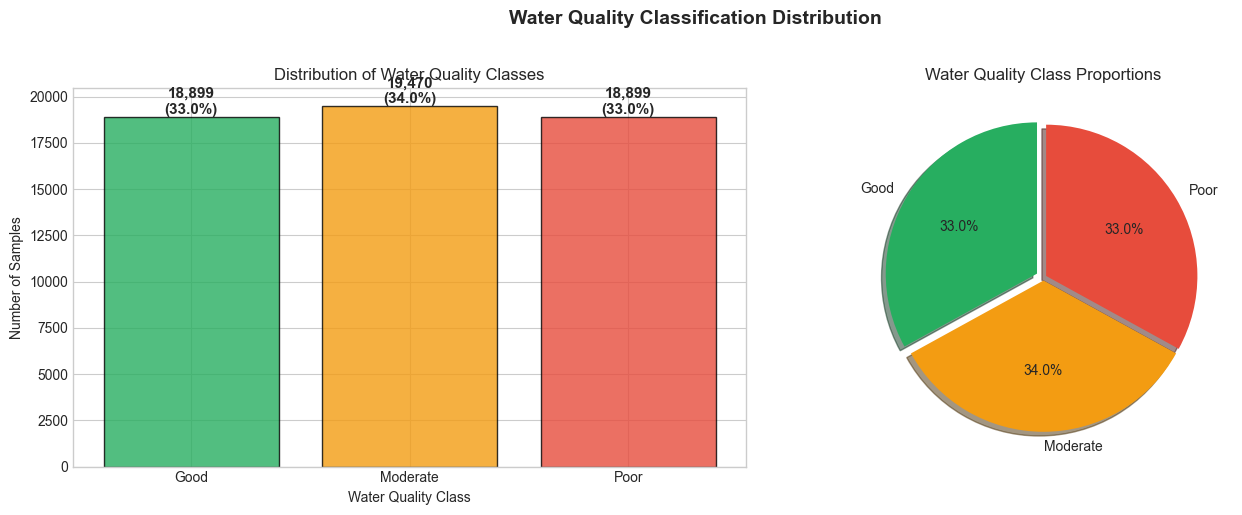

In [10]:
# Visualize class distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
ax1 = axes[0]
colors = {'Good': '#27ae60', 'Moderate': '#f39c12', 'Poor': '#e74c3c'}
class_order = ['Good', 'Moderate', 'Poor']

bars = ax1.bar(class_order, [class_counts[c] for c in class_order], 
               color=[colors[c] for c in class_order], edgecolor='black', alpha=0.8)

# Add value labels
for bar, class_name in zip(bars, class_order):
    height = bar.get_height()
    pct = class_percentages[class_name]
    ax1.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height):,}\n({pct:.1f}%)',
             ha='center', va='bottom', fontsize=11, fontweight='bold')

ax1.set_xlabel('Water Quality Class')
ax1.set_ylabel('Number of Samples')
ax1.set_title('Distribution of Water Quality Classes')

# Pie chart
ax2 = axes[1]
explode = (0.05, 0.02, 0.02)
ax2.pie([class_counts[c] for c in class_order], 
        labels=class_order, 
        autopct='%1.1f%%',
        colors=[colors[c] for c in class_order], 
        explode=explode,
        shadow=True, 
        startangle=90)
ax2.set_title('Water Quality Class Proportions')

plt.suptitle('Water Quality Classification Distribution', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 5. Class Characteristics Analysis

### What we're doing
Examining the characteristics of each water quality class to verify our classification makes scientific sense.

### What to verify
- Good class should have low chl_a, low tss, high secchi
- Poor class should have high chl_a, high tss, low secchi
- Classes should be clearly separable

In [11]:
# Summary statistics by class
print(f"{'='*60}")
print(f"CLASS CHARACTERISTICS SUMMARY")
print(f"{'='*60}")

for class_name in ['Good', 'Moderate', 'Poor']:
    class_data = df[df['water_quality_class'] == class_name]
    print(f"\n🌊 {class_name.upper()} CLASS (n={len(class_data):,}):")
    print(f"   Chlorophyll-a: {class_data['chl_a'].median():.2f} μg/L (median)")
    print(f"   TSS: {class_data['tss'].median():.2f} mg/L (median)")
    print(f"   Secchi: {class_data['secchi'].median():.2f} m (median)")
    print(f"   Composite Score: {class_data['wq_score'].median():.1f} (median)")

CLASS CHARACTERISTICS SUMMARY

🌊 GOOD CLASS (n=18,899):
   Chlorophyll-a: 3.82 μg/L (median)
   TSS: 4.40 mg/L (median)
   Secchi: 1.60 m (median)
   Composite Score: 74.4 (median)

🌊 MODERATE CLASS (n=19,470):
   Chlorophyll-a: 9.00 μg/L (median)
   TSS: 10.00 mg/L (median)
   Secchi: 0.90 m (median)
   Composite Score: 50.4 (median)

🌊 POOR CLASS (n=18,899):
   Chlorophyll-a: 24.00 μg/L (median)
   TSS: 22.00 mg/L (median)
   Secchi: 0.50 m (median)
   Composite Score: 25.1 (median)


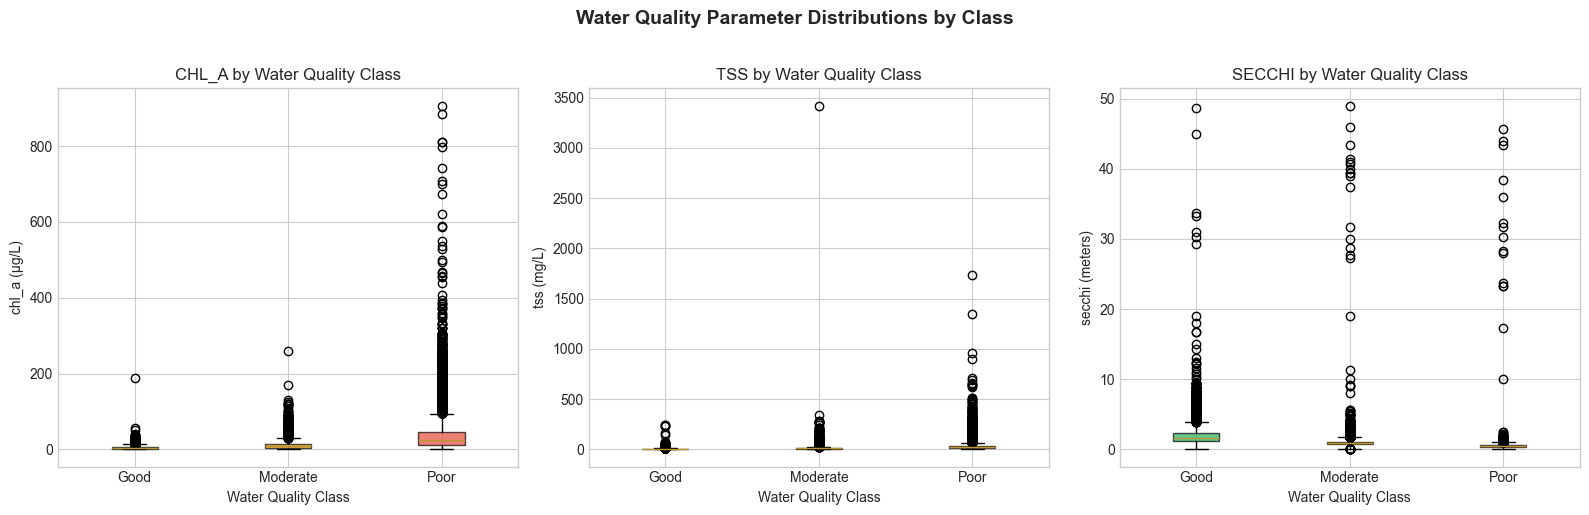

In [12]:
# Box plots showing parameter distributions by class
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

params = ['chl_a', 'tss', 'secchi']
units = ['μg/L', 'mg/L', 'meters']
colors = {'Good': '#27ae60', 'Moderate': '#f39c12', 'Poor': '#e74c3c'}

for i, (param, unit) in enumerate(zip(params, units)):
    ax = axes[i]
    
    # Create box plot
    class_order = ['Good', 'Moderate', 'Poor']
    bp = ax.boxplot([df[df['water_quality_class'] == c][param].dropna() for c in class_order],
                    labels=class_order, patch_artist=True)
    
    # Color boxes
    for patch, color in zip(bp['boxes'], [colors[c] for c in class_order]):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    
    ax.set_xlabel('Water Quality Class')
    ax.set_ylabel(f'{param} ({unit})')
    ax.set_title(f'{param.upper()} by Water Quality Class')

plt.suptitle('Water Quality Parameter Distributions by Class', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [13]:
# Detailed statistical comparison
print(f"\n{'='*60}")
print(f"DETAILED CLASS STATISTICS")
print(f"{'='*60}")

class_stats = df.groupby('water_quality_class')[['chl_a', 'tss', 'secchi', 'wq_score']].agg(
    ['mean', 'median', 'std', 'min', 'max']
).round(2)

print("\n")
class_stats


DETAILED CLASS STATISTICS




chl_a                                tss                \
                      mean median    std   min     max   mean median    std   
water_quality_class                                                           
Good                 4.850  3.820  4.020 0.020 189.000  5.590  4.400  6.070   
Moderate            11.720  9.000 10.150 0.020 260.000 13.510 10.000 27.950   
Poor                37.110 24.000 44.130 0.300 907.000 31.760 22.000 39.820   

                                   secchi                           wq_score  \
                      min      max   mean median   std   min    max     mean   
water_quality_class                                                            
Good                0.100  246.000  1.950  1.600 1.330 0.000 48.670   76.010   
Moderate            0.500 3420.000  0.990  0.900 1.160 0.000 49.000   50.250   
Poor                1.000 1733.000  0.510  0.500 0.910 0.000 45.670   23.730   

                                                
                    median   std    min    max  
water_quality_class                             
Good                74.430 9.890 61.710 99.500  
Moderate            50.370 6.700 38.400 61.710  
Poor                25.140 9.910  0.180 38.400

## 6. Validation: Scientific Reasonability Check

### What we're doing
Verifying that our classification aligns with scientific expectations.

### Expected Patterns
1. **Good → Poor**: chl_a should increase
2. **Good → Poor**: tss should increase  
3. **Good → Poor**: secchi should decrease

In [14]:
# Scientific validation
print(f"{'='*60}")
print(f"SCIENTIFIC VALIDATION")
print(f"{'='*60}")

# Calculate median values for each class
medians = df.groupby('water_quality_class')[['chl_a', 'tss', 'secchi']].median()

# Check chl_a trend (should increase from Good to Poor)
chl_a_trend = medians.loc['Poor', 'chl_a'] > medians.loc['Moderate', 'chl_a'] > medians.loc['Good', 'chl_a']
print(f"\n1️⃣ Chlorophyll-a increases from Good to Poor: {'✅ PASSED' if chl_a_trend else '❌ FAILED'}")
print(f"   Good: {medians.loc['Good', 'chl_a']:.2f} → Moderate: {medians.loc['Moderate', 'chl_a']:.2f} → Poor: {medians.loc['Poor', 'chl_a']:.2f}")

# Check tss trend (should increase from Good to Poor)
tss_trend = medians.loc['Poor', 'tss'] > medians.loc['Moderate', 'tss'] > medians.loc['Good', 'tss']
print(f"\n2️⃣ TSS increases from Good to Poor: {'✅ PASSED' if tss_trend else '❌ FAILED'}")
print(f"   Good: {medians.loc['Good', 'tss']:.2f} → Moderate: {medians.loc['Moderate', 'tss']:.2f} → Poor: {medians.loc['Poor', 'tss']:.2f}")

# Check secchi trend (should decrease from Good to Poor)
secchi_trend = medians.loc['Good', 'secchi'] > medians.loc['Moderate', 'secchi'] > medians.loc['Poor', 'secchi']
print(f"\n3️⃣ Secchi depth decreases from Good to Poor: {'✅ PASSED' if secchi_trend else '❌ FAILED'}")
print(f"   Good: {medians.loc['Good', 'secchi']:.2f} → Moderate: {medians.loc['Moderate', 'secchi']:.2f} → Poor: {medians.loc['Poor', 'secchi']:.2f}")

if all([chl_a_trend, tss_trend, secchi_trend]):
    print(f"\n🎉 All scientific validation checks PASSED!")
    print("   Our classification aligns with expected water quality patterns.")
else:
    print(f"\n⚠️ Some validation checks failed - review classification logic.")

SCIENTIFIC VALIDATION

1️⃣ Chlorophyll-a increases from Good to Poor: ✅ PASSED
   Good: 3.82 → Moderate: 9.00 → Poor: 24.00

2️⃣ TSS increases from Good to Poor: ✅ PASSED
   Good: 4.40 → Moderate: 10.00 → Poor: 22.00

3️⃣ Secchi depth decreases from Good to Poor: ✅ PASSED
   Good: 1.60 → Moderate: 0.90 → Poor: 0.50

🎉 All scientific validation checks PASSED!
   Our classification aligns with expected water quality patterns.


## 7. Class Distribution by Water Body Type

### What we're doing
Examining if water quality class distribution varies by water body type.

In [15]:
# Cross-tabulation of classes by water body type
print(f"{'='*60}")
print(f"CLASS DISTRIBUTION BY WATER BODY TYPE")
print(f"{'='*60}")

crosstab = pd.crosstab(df['type'], df['water_quality_class'], normalize='index') * 100
crosstab = crosstab[['Good', 'Moderate', 'Poor']]  # Order columns
print("\nPercentage of each class within each water body type:")
print(crosstab.round(1))

CLASS DISTRIBUTION BY WATER BODY TYPE

Percentage of each class within each water body type:
water_quality_class   Good  Moderate   Poor
type                                       
Estuary             34.200    41.200 24.600
Facility            25.000    50.000 25.000
Lake                38.000    24.500 37.500
Stream              27.500    37.300 35.200


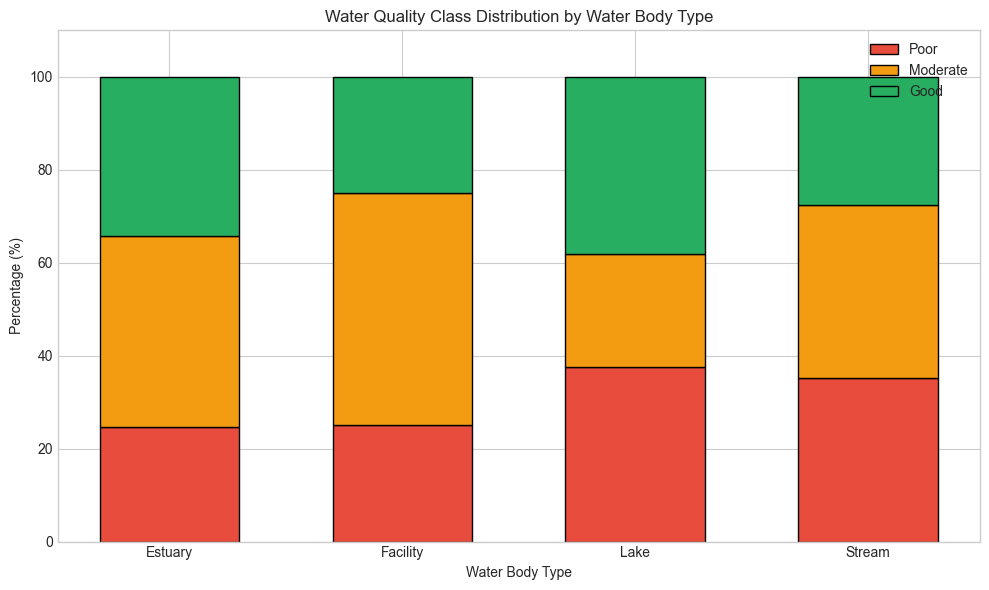

In [16]:
# Stacked bar chart
fig, ax = plt.subplots(figsize=(10, 6))

water_types = crosstab.index.tolist()
x = np.arange(len(water_types))
width = 0.6

colors = {'Good': '#27ae60', 'Moderate': '#f39c12', 'Poor': '#e74c3c'}

bottom = np.zeros(len(water_types))
for class_name in ['Poor', 'Moderate', 'Good']:  # Stack from bottom to top
    values = crosstab[class_name].values
    ax.bar(x, values, width, bottom=bottom, label=class_name, color=colors[class_name], edgecolor='black')
    bottom += values

ax.set_xlabel('Water Body Type')
ax.set_ylabel('Percentage (%)')
ax.set_title('Water Quality Class Distribution by Water Body Type')
ax.set_xticks(x)
ax.set_xticklabels(water_types)
ax.legend(loc='upper right')
ax.set_ylim(0, 110)

plt.tight_layout()
plt.show()

## 8. Creating Numeric Labels for Modeling

### What we're doing
Converting categorical class labels to numeric for machine learning algorithms.

In [17]:
# Create numeric labels
print(f"{'='*60}")
print(f"CREATING NUMERIC LABELS")
print(f"{'='*60}")

# Label mapping
label_mapping = {'Poor': 0, 'Moderate': 1, 'Good': 2}
reverse_mapping = {v: k for k, v in label_mapping.items()}

df['water_quality_label'] = df['water_quality_class'].map(label_mapping)

print(f"\n📝 Label Mapping:")
for class_name, label in label_mapping.items():
    print(f"   • {class_name} → {label}")

print(f"\n✅ Numeric label column 'water_quality_label' created!")

# Verify
print(f"\n📊 Label Distribution:")
print(df['water_quality_label'].value_counts().sort_index())

CREATING NUMERIC LABELS

📝 Label Mapping:
   • Poor → 0
   • Moderate → 1
   • Good → 2

✅ Numeric label column 'water_quality_label' created!

📊 Label Distribution:
water_quality_label
0    18899
1    19470
2    18899
Name: count, dtype: int64


## 9. Final Dataset Freeze

### What we're doing
Saving the dataset with the target variable for use in downstream notebooks.

### New columns added
- `chl_a_score`: Normalized chlorophyll-a score (0-100, higher = better)
- `tss_score`: Normalized TSS score (0-100, higher = better)
- `secchi_score`: Normalized Secchi score (0-100, higher = better)
- `wq_score`: Composite water quality score (0-100, higher = better)
- `water_quality_class`: Categorical target (Good/Moderate/Poor)
- `water_quality_label`: Numeric target (0/1/2)

In [18]:
# Save the processed dataset
import os

# Ensure processed_data directory exists
os.makedirs('../processed_data', exist_ok=True)

OUTPUT_PATH = '../processed_data/dataset_with_classes.csv'

print(f"{'='*60}")
print(f"SAVING PROCESSED DATASET")
print(f"{'='*60}")

# Save
df.to_csv(OUTPUT_PATH, index=False)

print(f"\n✅ Dataset saved to: {OUTPUT_PATH}")
print(f"\n📊 Final Dataset Summary:")
print(f"   • Total records: {len(df):,}")
print(f"   • Total columns: {len(df.columns)}")
print(f"   • New columns added: {['chl_a_score', 'tss_score', 'secchi_score', 'wq_score', 'water_quality_class', 'water_quality_label']}")

SAVING PROCESSED DATASET

✅ Dataset saved to: ../processed_data/dataset_with_classes.csv

📊 Final Dataset Summary:
   • Total records: 57,268
   • Total columns: 51
   • New columns added: ['chl_a_score', 'tss_score', 'secchi_score', 'wq_score', 'water_quality_class', 'water_quality_label']


In [19]:
# Final sanity check
print(f"\n{'='*60}")
print(f"FINAL SANITY CHECK")
print(f"{'='*60}")

# Verify no missing values in target
missing_class = df['water_quality_class'].isnull().sum()
missing_label = df['water_quality_label'].isnull().sum()

print(f"\n1️⃣ Missing values in target columns:")
print(f"   • water_quality_class: {missing_class}")
print(f"   • water_quality_label: {missing_label}")

# Verify class balance
print(f"\n2️⃣ Final class distribution:")
for class_name in ['Good', 'Moderate', 'Poor']:
    count = (df['water_quality_class'] == class_name).sum()
    pct = count / len(df) * 100
    print(f"   • {class_name}: {count:,} ({pct:.1f}%)")

# Confirm scientific validity
print(f"\n3️⃣ Scientific validity confirmed: ✅")
print(f"   • Good water has low chl_a, low tss, high secchi")
print(f"   • Poor water has high chl_a, high tss, low secchi")


FINAL SANITY CHECK

1️⃣ Missing values in target columns:
   • water_quality_class: 0
   • water_quality_label: 0

2️⃣ Final class distribution:
   • Good: 18,899 (33.0%)
   • Moderate: 19,470 (34.0%)
   • Poor: 18,899 (33.0%)

3️⃣ Scientific validity confirmed: ✅
   • Good water has low chl_a, low tss, high secchi
   • Poor water has high chl_a, high tss, low secchi
